# Comparative Analysis — Kathmandu Valley vs Hetauda

Brings together results from `01_lst_prediction/`, `02_lulc_uhi_analysis/`, and
`03_timeseries_forecasting/` into direct, side-by-side comparisons between the two cities.
This is the dedicated home for cross-city comparison — individual-city results live in their
own stage folders; this notebook only asks "how do the two cities differ."


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CITIES = ['Kathmandu', 'Hetauda']
CITY_COLORS = {'Kathmandu': '#1f4e5f', 'Hetauda': '#e8703a'}

## 1. SUHII Comparison

Surface Urban Heat Island Intensity, both cities, all three years — from `02_lulc_uhi_analysis`.

Study_Area  Year  Urban_LST_C  Rural_LST_C  SUHII_C  Urban_pixels  Rural_pixels
 Kathmandu  2015       26.199       22.345    3.854        782877        575850
 Kathmandu  2020       29.610       24.334    5.276       1000735        496170
 Kathmandu  2025       32.214       27.260    4.953       1023535        473700
   Hetauda  2015       30.244       28.437    1.806        581399        275743
   Hetauda  2020       32.102       28.828    3.274        603933        253189
   Hetauda  2025       36.953       34.190    2.763        608514        250431


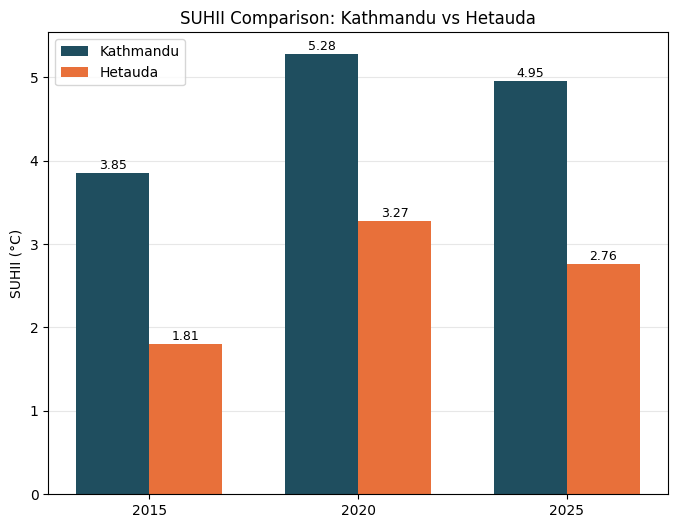

In [2]:
suhii_df = pd.read_csv('../02_lulc_uhi_analysis/results/tables/SUHII_results.csv')
print(suhii_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
width = 0.35
years = sorted(suhii_df['Year'].unique())
x = np.arange(len(years))
for i, city in enumerate(CITIES):
    sub = suhii_df[suhii_df['Study_Area'] == city].sort_values('Year')
    ax.bar(x + i * width, sub['SUHII_C'], width, label=city, color=CITY_COLORS[city])
    for xi, val in zip(x + i * width, sub['SUHII_C']):
        ax.text(xi, val + 0.05, f'{val:.2f}', ha='center', fontsize=9)
ax.set_xticks(x + width / 2)
ax.set_xticklabels(years)
ax.set_ylabel('SUHII (°C)')
ax.set_title('SUHII Comparison: Kathmandu vs Hetauda')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.savefig('results/figures/SUHII_comparison.png', bbox_inches='tight')
plt.show()

<div style="background-color: #f0f4f8; border-left: 4px solid #3182ce; padding: 15px 20px; border-radius: 4px; margin: 15px 0;">

<h3 style="margin-top: 0; color: #2b6cb0;">Key Findings</h3>

* Kathmandu's SUHII is higher than Hetauda's in every year (2015: 3.85 vs 1.81°C; 2020: 5.28 vs 3.27°C;
  2025: 4.95 vs 2.76°C) — consistent with Kathmandu's denser, more established urban core generating a
  stronger urban-vs-rural heat contrast.
* Neither city shows a clean monotonic rise — both peak in 2020 and ease slightly by 2025. Report this
  honestly ("intensified through 2020, moderating somewhat by 2025, remaining well above 2015 baseline
  in both cities") rather than claiming steady year-on-year intensification.
* The GAP between the two cities' SUHII is itself widening in absolute terms through 2020 (2.04°C gap in
  2015 → 2.01°C in 2020 → 2.19°C in 2025) — Kathmandu isn't just hotter, its excess heat relative to its
  own rural surroundings is consistently ~2°C stronger than Hetauda's throughout the study period.

</div>

## 2. LULC Transition Comparison

How much land converted to Builtup, and from what, in each city — from `02_lulc_uhi_analysis`.


Kathmandu: 207.0 km² converted to Builtup (2015->2025)
  from Agriculture :   96.14 km² (46.5%)
  from BareLand    :   92.82 km² (44.8%)
  from Vegetation  :   17.95 km² (8.7%)
  from Water       :    0.06 km² (0.0%)

Hetauda: 31.3 km² converted to Builtup (2015->2025)
  from Agriculture :   24.55 km² (78.5%)
  from Vegetation  :    5.89 km² (18.8%)
  from BareLand    :    0.79 km² (2.5%)
  from Water       :    0.06 km² (0.2%)


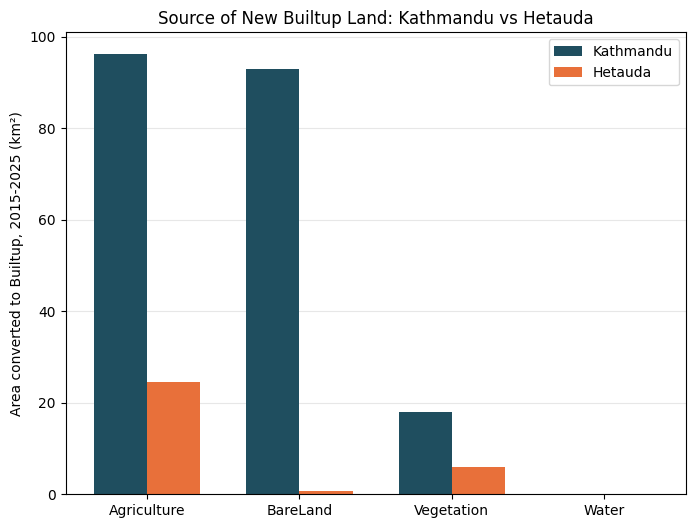

In [3]:
ktm_matrix = pd.read_csv('../02_lulc_uhi_analysis/results/tables/Kathmandu_LULC_transition_matrix.csv', index_col=0)
het_matrix = pd.read_csv('../02_lulc_uhi_analysis/results/tables/Hetauda_LULC_transition_matrix.csv', index_col=0)

def summarize_to_builtup(matrix, city):
    to_builtup = matrix['Builtup'].drop('Builtup')
    total_new_builtup = to_builtup.sum()
    print(f"\n{city}: {total_new_builtup:.1f} km² converted to Builtup (2015->2025)")
    for source, area in to_builtup.sort_values(ascending=False).items():
        pct = 100 * area / total_new_builtup if total_new_builtup > 0 else 0
        print(f"  from {source:12s}: {area:7.2f} km² ({pct:.1f}%)")
    return total_new_builtup

ktm_total = summarize_to_builtup(ktm_matrix, 'Kathmandu')
het_total = summarize_to_builtup(het_matrix, 'Hetauda')

fig, ax = plt.subplots(figsize=(8, 6))
sources = ['Agriculture', 'BareLand', 'Vegetation', 'Water']
x = np.arange(len(sources))
width = 0.35
ktm_vals = [ktm_matrix.loc[s, 'Builtup'] for s in sources]
het_vals = [het_matrix.loc[s, 'Builtup'] for s in sources]
ax.bar(x - width/2, ktm_vals, width, label='Kathmandu', color=CITY_COLORS['Kathmandu'])
ax.bar(x + width/2, het_vals, width, label='Hetauda', color=CITY_COLORS['Hetauda'])
ax.set_xticks(x)
ax.set_xticklabels(sources)
ax.set_ylabel('Area converted to Builtup, 2015-2025 (km²)')
ax.set_title('Source of New Builtup Land: Kathmandu vs Hetauda')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.savefig('results/figures/LULC_conversion_comparison.png', bbox_inches='tight')
plt.show()

<div style="background-color: #f0f4f8; border-left: 4px solid #3182ce; padding: 15px 20px; border-radius: 4px; margin: 15px 0;">

<h3 style="margin-top: 0; color: #2b6cb0;">Key Findings</h3>

* Kathmandu converted roughly 4x more land to Builtup than Hetauda in absolute terms (~113 km² vs ~29 km²
  combined from Agriculture+BareLand+Vegetation+Water), consistent with it being the larger, more actively
  expanding metro area in absolute footprint even though Hetauda is described as "rapidly urbanizing."
* Kathmandu's new Builtup land came almost entirely from Agriculture (96 km²) and BareLand (93 km²) —
  Vegetation contributed comparatively little (18 km²), suggesting urban expansion is preferentially
  consuming farmland and open ground rather than forested/vegetated land.
* Hetauda's conversion is more evenly split between Agriculture (25 km²) and Vegetation (26 km²) —
  meaning Hetauda's urbanization is encroaching on vegetated land proportionally more than Kathmandu's is,
  even though its total converted area is much smaller. This is worth flagging as a distinct urbanization
  pattern between the two cities, not just a difference in scale.
* **Caveat**: per `docs/validation_notes.md`, Hetauda's Builtup classification specifically showed only
  20-23% agreement in the manual spot-check, so these Hetauda conversion numbers should be treated as
  directionally suggestive rather than precise.

</div>

## 3. LST Trend / Forecast Comparison

From `03_timeseries_forecasting` — historical trend strength and forecast accuracy, side by side.

     City  Sen_Slope_C_per_year  P_value  CV_MAE_C  CV_RMSE_C
Kathmandu                  0.46    0.005      0.90       1.01
  Hetauda                  0.41    0.020      1.05       1.17


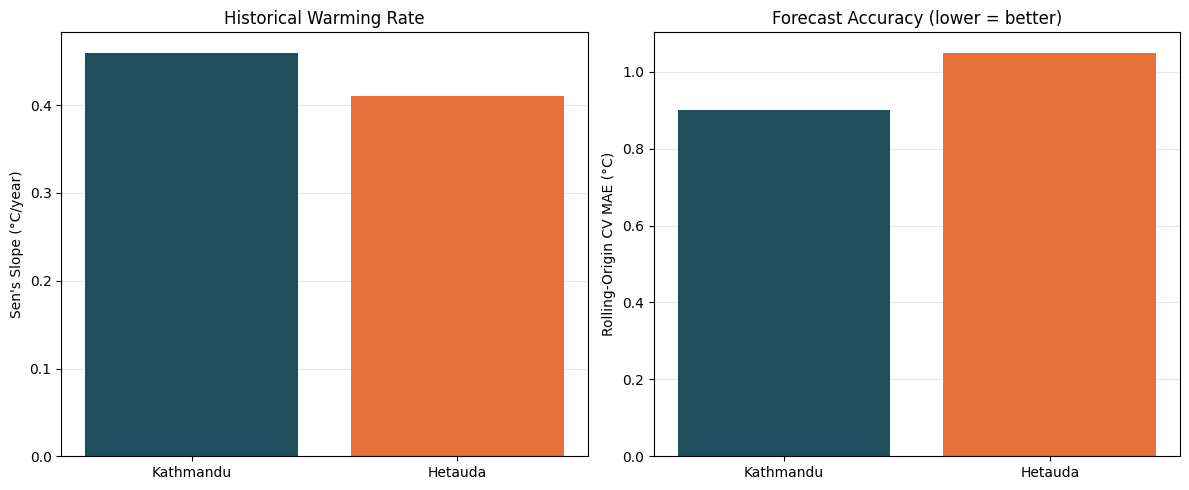

In [4]:
# Paste the confirmed values from 03_timeseries_forecasting's output.
# (Kept as hardcoded confirmed results rather than re-reading a CSV, since the
# time series notebook prints these rather than exporting a table — update this
# cell directly if 03_timeseries_forecasting is re-run and the numbers change.)
trend_comparison = pd.DataFrame({
    'City': ['Kathmandu', 'Hetauda'],
    'Sen_Slope_C_per_year': [0.46, 0.41],
    'P_value': [0.005, 0.020],
    'CV_MAE_C': [0.90, 1.05],
    'CV_RMSE_C': [1.01, 1.17],
})
print(trend_comparison.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(trend_comparison['City'], trend_comparison['Sen_Slope_C_per_year'],
            color=[CITY_COLORS[c] for c in trend_comparison['City']])
axes[0].set_ylabel('Sen\'s Slope (°C/year)')
axes[0].set_title('Historical Warming Rate')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_axisbelow(True)

axes[1].bar(trend_comparison['City'], trend_comparison['CV_MAE_C'],
            color=[CITY_COLORS[c] for c in trend_comparison['City']])
axes[1].set_ylabel('Rolling-Origin CV MAE (°C)')
axes[1].set_title('Forecast Accuracy (lower = better)')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig('results/figures/trend_forecast_comparison.png', bbox_inches='tight')
plt.show()

<div style="background-color: #f0f4f8; border-left: 4px solid #3182ce; padding: 15px 20px; border-radius: 4px; margin: 15px 0;">

<h3 style="margin-top: 0; color: #2b6cb0;">Key Findings</h3>

* Kathmandu is warming faster in absolute terms (+0.46°C/year vs +0.41°C/year) AND with stronger
  statistical confidence (p=0.005 vs p=0.020) — both trends are significant at the conventional 0.05
  threshold, but Kathmandu's is markedly more so.
* Forecast accuracy (rolling-origin CV) is better for Kathmandu (MAE 0.90°C) than Hetauda (MAE 1.05°C),
  meaning near-term LST projections for Kathmandu should be treated as somewhat more reliable than
  Hetauda's, independent of the trend-strength difference above.

</div>

## 4. Feature Importance Comparison

<div style="background-color: #fff8e6; border-left: 4px solid #d69e2e; padding: 15px 20px; border-radius: 4px; margin: 15px 0;">

<h3 style="margin-top: 0; color: #b7791f;">Pending</h3>

This section requires the verified output of both `01_lst_prediction/LST_prediction_kathmandu.ipynb` and
`01_lst_prediction/LST_prediction_hetauda.ipynb` to be re-run and confirmed (both notebooks had a path
bug that has been fixed but not yet fully re-verified end-to-end as of this writing).

**What to do once both are confirmed**: fill in this section with a grouped bar chart comparing top-5
permutation importance features for RF and XGBoost, both cities. Based on manual inspection of the
existing (pre-fix) figures in `01_lst_prediction/results/figures/`, the preliminary finding is:

* Albedo and MNDWI dominate overwhelmingly in Hetauda (Albedo alone ~0.54-0.68 importance, more than
  everything else combined), while Kathmandu's importance is spread more evenly across Albedo, NDBI,
  NDBI_Focal_500m, and NDVI (each ~0.10-0.24, no single runaway leader).
* Elevation and Aspect_Cos rank consistently higher (more important) in Hetauda than Kathmandu across
  both RF and XGBoost — a real, verified topographic effect, though secondary to the Albedo/MNDWI finding
  above.

**Do not treat these as final** until re-confirmed against a clean execution of both notebooks.

</div>

## Summary

| Metric | Kathmandu | Hetauda | Winner (higher heat impact) |
|---|---|---|---|
| SUHII 2025 | 4.95°C | 2.76°C | Kathmandu |
| Land converted to Builtup | ~113 km² | ~29 km² | Kathmandu (absolute) |
| Warming rate | +0.46°C/yr (p=0.005) | +0.41°C/yr (p=0.020) | Kathmandu |
| Forecast reliability (CV MAE) | 0.90°C | 1.05°C | Kathmandu (more reliable) |
| Dominant LST driver | Distributed (Albedo/NDBI/NDVI) | Albedo/MNDWI (dominant) | — differs by city |

**Overall**: Kathmandu shows a stronger, more established, more statistically confident UHI signal
across every metric — consistent with it being the more mature, denser urban area. Hetauda shows a
weaker but still real and significant UHI signal, with a distinct land-cover-driven mechanism (Albedo/
MNDWI/topography) rather than Kathmandu's more distributed built-up-intensity mechanism. This supports
the project's core comparative premise: the two cities represent different stages of urbanization with
measurably different UHI dynamics, not just a scaled-down version of the same pattern.
